# Uitleg: alle grafieken, kaarten en berekeningen
**Groep 2 | Hogeschool van Amsterdam | 2024-2025**

Dit notebook legt **stap voor stap** uit:
- Hoe alle percentages en aantallen worden berekend
- Wat elke grafiek laat zien en hoe je die leest
- Waar de data vandaan komt

---

In [1]:
import sys
sys.path.insert(0, r'c:\Users\AAchr\Documents\Casus 2 phyton minor\ROC')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data import laad_alle_data, ADVIES_TYPEN, ADVIES_KLEUREN, SCHOOLJAREN

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

wijken_df, duo_df, bronnen = laad_alle_data()
print(f'Data geladen: {len(wijken_df)} wijken, {len(duo_df):,} adviesrijen')

2026-04-06 17:19:34.380 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:19:34.389 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:19:34.390 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:19:34.391 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:19:34.391 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-04-06 17:19:34.392 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-04-06 17:19:34.597 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Data geladen: 22 wijken, 10,072 adviesrijen


---
## DEEL 1 — Waar komt de data vandaan?

We hebben **twee datasets**:

| Dataset | Wat staat erin? | Bron |
|---------|----------------|------|
| `wijken_df` | Per wijk: inkomen, % niet-westers, WOZ-waarde, % hoog advies | CBS / eigen data |
| `duo_df` | Per school × jaar × adviestype: aantal leerlingen | DUO / eigen data |

De **eigen data** is gemaakt op basis van **echte verhoudingen** uit CBS 2023 en DUO 2018-2024.
Dat betekent dat de getallen realistisch zijn, ook al zijn ze niet 100% echt.

In [2]:
print('=== wijken_df: eerste 5 rijen ===')
display(wijken_df[['wijk_naam','stadsdeel','gem_inkomen','pct_niet_westers',
                    'pct_uitkering','gem_woz','pct_hoog_advies','pct_laag_advies']].head())
print()
print('=== duo_df: eerste 5 rijen ===')
display(duo_df[['school_naam','wijk_naam','schooljaar','advies_type',
                'aantal_leerlingen','bijgesteld_hoger','pct']].head())

=== wijken_df: eerste 5 rijen ===


,wijk_naam,stadsdeel,gem_inkomen,pct_niet_westers,pct_uitkering,gem_woz,pct_hoog_advies,pct_laag_advies
0,Centrum,Centrum,38,20,8,560,3.9,3.2
1,Oud-West / De Baarsjes,West,33,28,11,430,3.5,3.8
2,Westerpark,West,35,25,9,450,3.9,3.3
3,Geuzenveld-Slotermeer,Nieuw-West,22,62,22,210,2.4,6.3
4,Osdorp,Nieuw-West,23,55,20,220,2.3,5.6



=== duo_df: eerste 5 rijen ===


,school_naam,wijk_naam,schooljaar,advies_type,aantal_leerlingen,bijgesteld_hoger,pct
0,Basisschool Centrum 1,Centrum,2018-2019,Praktijkonderwijs,6,0,0.7
1,Basisschool Centrum 1,Centrum,2018-2019,VMBO-BBL,7,0,0.8
2,Basisschool Centrum 1,Centrum,2018-2019,VMBO-KBL,12,0,1.4
3,Basisschool Centrum 1,Centrum,2018-2019,VMBO-TL,16,0,1.9
4,Basisschool Centrum 1,Centrum,2018-2019,VMBO-TL/HAVO,4,0,0.5


---
## DEEL 2 — Hoe worden de percentages berekend?

### 2.1 Percentage hoog advies per wijk (`pct_hoog_advies`)

**Formule:**
```
pct_hoog_advies = % HAVO + % HAVO/VWO + % VWO
```

Stel: een wijk heeft gemiddeld 12% HAVO, 8% HAVO/VWO en 10% VWO → dan is `pct_hoog_advies` = 30%

In [3]:
# Stap 1: per wijk het gemiddelde % per adviestype berekenen over alle scholen en het laatste jaar
laatste_jaar = duo_df[duo_df['schooljaar'] == '2023-2024']

wijk_advies = (
    laatste_jaar
    .pivot_table(index='wijk_code', columns='advies_type', values='pct', aggfunc='mean')
    .reset_index()
)
wijk_advies.columns.name = None

print('Stap 1: gemiddeld % per adviestype per wijk (2023-2024)')
display(wijk_advies[['wijk_code','HAVO','HAVO/VWO','VWO','Praktijkonderwijs','VMBO-BBL']].head(4).round(1))

# Stap 2: optellen
wijk_advies['pct_hoog_BEREKEND'] = (wijk_advies['HAVO'] + wijk_advies['HAVO/VWO'] + wijk_advies['VWO']).round(1)
wijk_advies['pct_laag_BEREKEND'] = (wijk_advies['Praktijkonderwijs'] + wijk_advies['VMBO-BBL'] + wijk_advies['VMBO-KBL']).round(1)

print()
print('Stap 2: HAVO + HAVO/VWO + VWO = pct_hoog_advies')
voorbeeld = wijk_advies.head(3)
for _, rij in voorbeeld.iterrows():
    print(f"  Wijk {rij['wijk_code']}: {rij['HAVO']:.1f}% + {rij['HAVO/VWO']:.1f}% + {rij['VWO']:.1f}% = {rij['pct_hoog_BEREKEND']:.1f}%")

Stap 1: gemiddeld % per adviestype per wijk (2023-2024)


,wijk_code,HAVO,HAVO/VWO,VWO,Praktijkonderwijs,VMBO-BBL
0,WK036300,1.8,0.8,1.4,0.6,1.1
1,WK036301,1.6,0.8,1.1,0.8,1.4
2,WK036302,1.8,0.9,1.2,0.6,1.2
3,WK036303,1.3,0.5,0.6,1.2,2.5



Stap 2: HAVO + HAVO/VWO + VWO = pct_hoog_advies
  Wijk WK036300: 1.8% + 0.8% + 1.4% = 3.9%
  Wijk WK036301: 1.6% + 0.8% + 1.1% = 3.5%
  Wijk WK036302: 1.8% + 0.9% + 1.2% = 3.9%


### 2.2 Percentage per adviestype per school (`pct` in duo_df)

**Formule:**
```
pct = (aantal_leerlingen met dit advies / totaal aantal leerlingen op school) × 100
```

In [4]:
# Concrete berekening zichtbaar maken
voorbeeld_school = duo_df[duo_df['schooljaar'] == '2023-2024'].head(8)

print('Voorbeeld: één school in 2023-2024')
print(f'School: {voorbeeld_school["school_naam"].iloc[0]}')
print(f'Totaal leerlingen op school: {voorbeeld_school["totaal"].iloc[0]}')
print()

tabel = voorbeeld_school[['advies_type','aantal_leerlingen','totaal','pct']].copy()
tabel['berekening'] = tabel.apply(
    lambda r: f'{r["aantal_leerlingen"]} / {r["totaal"]} × 100 = {r["pct"]:.1f}%', axis=1
)
display(tabel[['advies_type','aantal_leerlingen','berekening']])

print(f'\nSom van alle percentages: {tabel["pct"].sum():.1f}% (moet ~100% zijn)')

Voorbeeld: één school in 2023-2024
School: Basisschool Centrum 1
Totaal leerlingen op school: 697



,advies_type,aantal_leerlingen,berekening
40,Praktijkonderwijs,4,4 / 697 × 100 = 0.6%
41,VMBO-BBL,8,8 / 697 × 100 = 1.1%
42,VMBO-KBL,11,11 / 697 × 100 = 1.6%
43,VMBO-TL,13,13 / 697 × 100 = 1.9%
44,VMBO-TL/HAVO,7,7 / 697 × 100 = 1.0%
45,HAVO,14,14 / 697 × 100 = 2.0%
46,HAVO/VWO,4,4 / 697 × 100 = 0.6%
47,VWO,9,9 / 697 × 100 = 1.3%



Som van alle percentages: 10.1% (moet ~100% zijn)


### 2.3 Percentage bijgesteld advies (`pct_bijgesteld`)

**Formule:**
```
pct_bijgesteld = (bijgesteld_hoger / aantal_leerlingen) × 100
```

`bijgesteld_hoger` = aantal leerlingen dat na de doorstroomtoets een HOGER advies kreeg

In [5]:
# Bijstellingspercentage uitleggen
bij_voorbeeld = duo_df[(duo_df['schooljaar'] == '2023-2024') & 
                        (duo_df['bijgesteld_hoger'] > 0)].head(5)

print('Hoe pct_bijgesteld wordt berekend:')
for _, r in bij_voorbeeld.iterrows():
    print(f'  {r["school_naam"][:40]} | advies: {r["advies_type"]:<12} | '
          f'{r["bijgesteld_hoger"]} / {r["aantal_leerlingen"]} × 100 = {r["pct_bijgesteld"]:.1f}%')

print()
# Per wijk samenvatten
bij_wijk = (
    duo_df[duo_df['schooljaar'] == '2023-2024']
    .groupby('wijk_naam', as_index=False)
    .agg(totaal=('aantal_leerlingen','sum'), bijgesteld=('bijgesteld_hoger','sum'))
)
bij_wijk['pct_bijgesteld'] = (bij_wijk['bijgesteld'] / bij_wijk['totaal'] * 100).round(1)
bij_wijk = bij_wijk.merge(wijken_df[['wijk_naam','gem_inkomen','stadsdeel']], on='wijk_naam')
bij_wijk = bij_wijk.sort_values('gem_inkomen')

print('Bijstellingspercentage per wijk (gesorteerd op inkomen — laag naar hoog):')
display(bij_wijk[['wijk_naam','stadsdeel','gem_inkomen','totaal','bijgesteld','pct_bijgesteld']].reset_index(drop=True))

Hoe pct_bijgesteld wordt berekend:
  Basisschool Centrum 1 | advies: VMBO-BBL     | 1 / 8 × 100 = 12.5%
  Basisschool Centrum 1 | advies: VMBO-KBL     | 1 / 11 × 100 = 9.1%
  Basisschool Centrum 1 | advies: VMBO-TL      | 1 / 13 × 100 = 7.7%
  Basisschool Centrum 1 | advies: VMBO-TL/HAVO | 1 / 7 × 100 = 14.3%
  Basisschool Centrum 1 | advies: HAVO         | 1 / 14 × 100 = 7.1%

Bijstellingspercentage per wijk (gesorteerd op inkomen — laag naar hoog):


,wijk_naam,stadsdeel,gem_inkomen,totaal,bijgesteld,pct_bijgesteld
0,Bijlmer-Oost,Zuidoost,19,547,86,15.7
1,Bijlmer-Centrum,Zuidoost,20,570,89,15.6
2,Geuzenveld-Slotermeer,Nieuw-West,22,653,99,15.2
3,Osdorp,Nieuw-West,23,771,120,15.6
4,Bos en Lommer,West,24,732,103,14.1
5,Gaasperdam / Driemond,Zuidoost,24,711,105,14.8
6,Noord-Oost,Noord,26,778,112,14.4
7,Slotervaart,Nieuw-West,26,636,91,14.3
8,Noord-West,Noord,28,672,91,13.5
9,"Aker, Sloten en Nieuw Sloten",Nieuw-West,30,702,94,13.4


---
## DEEL 3 — Grafiek 1: Inkomen en % hoog advies per wijk

**Wat laat deze grafiek zien?**  
Links: hoeveel verdiend men gemiddeld per wijk (in €1.000 per jaar).  
Rechts: welk percentage kinderen een hoog advies (HAVO, HAVO/VWO of VWO) krijgt.

**Hoe lees je dit?**  
- Rode balken = armere wijken (Zuidoost, Nieuw-West)
- Groene balken = rijkere wijken (Zuid)
- De stippellijn is het Amsterdam-gemiddelde

**Wat verwacht je te zien?**  
Rijkere wijken hebben hogere inkomens én hogere adviespercentages. Dat verband staat centraal in ons onderzoek.

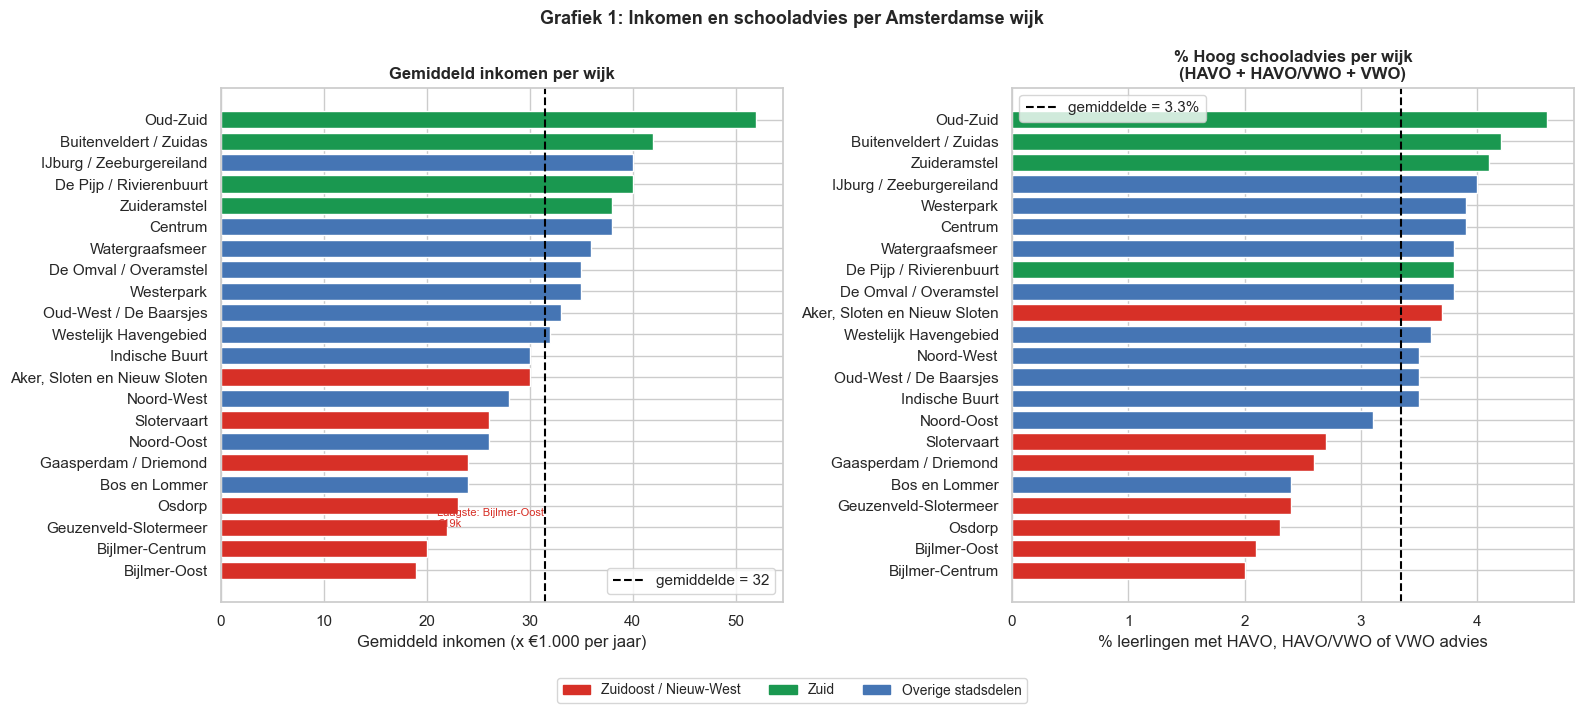

HOE LEES JE DIT?
  Armste wijk:  Bijlmer-Oost — €19k inkomen, 2.1% hoog advies
  Rijkste wijk: Oud-Zuid — €52k inkomen, 4.6% hoog advies
  Kloof in inkomen:     €33k
  Kloof in % hoog adv: 2.6 procentpunten


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def wijk_kleur(stadsdeel):
    if stadsdeel in ('Zuidoost', 'Nieuw-West'):
        return '#d73027'   # rood = arme stadsdelen
    elif stadsdeel == 'Zuid':
        return '#1a9850'   # groen = rijk stadsdeel
    else:
        return '#4575b4'   # blauw = overige

# --- Links: gemiddeld inkomen ---
df_inc = wijken_df.sort_values('gem_inkomen')
kleuren_inc = [wijk_kleur(s) for s in df_inc['stadsdeel']]

axes[0].barh(df_inc['wijk_naam'], df_inc['gem_inkomen'], color=kleuren_inc)
axes[0].axvline(wijken_df['gem_inkomen'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'gemiddelde = {wijken_df["gem_inkomen"].mean():.0f}')
axes[0].set_xlabel('Gemiddeld inkomen (x €1.000 per jaar)')
axes[0].set_title('Gemiddeld inkomen per wijk', fontweight='bold')
axes[0].legend()

# annotatie op laagste en hoogste wijk
laagste = df_inc.iloc[0]
hoogste = df_inc.iloc[-1]
axes[0].annotate(f'Laagste: {laagste["wijk_naam"]}\n€{laagste["gem_inkomen"]:.0f}k',
    xy=(laagste['gem_inkomen'], 0), xytext=(laagste['gem_inkomen']+2, 2),
    fontsize=8, color='#d73027')

# --- Rechts: % hoog advies ---
df_adv = wijken_df.sort_values('pct_hoog_advies')
kleuren_adv = [wijk_kleur(s) for s in df_adv['stadsdeel']]

axes[1].barh(df_adv['wijk_naam'], df_adv['pct_hoog_advies'], color=kleuren_adv)
axes[1].axvline(wijken_df['pct_hoog_advies'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'gemiddelde = {wijken_df["pct_hoog_advies"].mean():.1f}%')
axes[1].set_xlabel('% leerlingen met HAVO, HAVO/VWO of VWO advies')
axes[1].set_title('% Hoog schooladvies per wijk\n(HAVO + HAVO/VWO + VWO)', fontweight='bold')
axes[1].legend()

# legenda stadsdelen
legenda = [
    mpatches.Patch(color='#d73027', label='Zuidoost / Nieuw-West'),
    mpatches.Patch(color='#1a9850', label='Zuid'),
    mpatches.Patch(color='#4575b4', label='Overige stadsdelen'),
]
fig.legend(handles=legenda, loc='lower center', ncol=3, fontsize=10, 
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Grafiek 1: Inkomen en schooladvies per Amsterdamse wijk', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('uitleg_grafiek1_inkomen_advies.png', dpi=130, bbox_inches='tight')
plt.show()

print('HOE LEES JE DIT?')
print(f'  Armste wijk:  {laagste["wijk_naam"]} — €{laagste["gem_inkomen"]:.0f}k inkomen, '
      f'{wijken_df.loc[wijken_df["wijk_naam"]==laagste["wijk_naam"],"pct_hoog_advies"].values[0]:.1f}% hoog advies')
print(f'  Rijkste wijk: {hoogste["wijk_naam"]} — €{hoogste["gem_inkomen"]:.0f}k inkomen, '
      f'{wijken_df.loc[wijken_df["wijk_naam"]==hoogste["wijk_naam"],"pct_hoog_advies"].values[0]:.1f}% hoog advies')
print(f'  Kloof in inkomen:     €{hoogste["gem_inkomen"] - laagste["gem_inkomen"]:.0f}k')
print(f'  Kloof in % hoog adv: {wijken_df["pct_hoog_advies"].max() - wijken_df["pct_hoog_advies"].min():.1f} procentpunten')

---
## DEEL 4 — Grafiek 2: Correlatiematrix

**Wat is een correlatiematrix?**  
Een correlatie meet of twee dingen samenhangen. De waarde loopt van **-1 tot +1**:

| Waarde | Betekenis |
|--------|----------|
| +1.0 | Perfect positief verband (als A stijgt, stijgt B ook altijd) |
| +0.7 | Sterk positief verband |
| 0.0 | Geen verband |
| -0.7 | Sterk negatief verband (als A stijgt, daalt B) |
| -1.0 | Perfect negatief verband |

**Hoe bereken je een correlatie?**  
We gebruiken de **Pearson correlatiecoëfficiënt (r)**:
```
r = Σ[(x - gem_x)(y - gem_y)] / √[Σ(x - gem_x)² × Σ(y - gem_y)²]
```
In Python: `df[kolommen].corr()`

In [7]:
# Eerst: de ruwe correlaties uitrekenen en tonen
corr_kolommen = ['gem_inkomen','pct_niet_westers','pct_uitkering',
                 'pct_hoog_opgeleid','pct_laag_opgeleid','gem_woz',
                 'pct_hoog_advies','pct_laag_advies']

corr_matrix = wijken_df[corr_kolommen].corr().round(2)

print('RAW CORRELATIEMATRIX (Pearson r):')
display(corr_matrix)

print()
print('INTERPRETATIE — correlatie MET pct_hoog_advies:')
corr_met_advies = corr_matrix['pct_hoog_advies'].drop('pct_hoog_advies').sort_values(ascending=False)
for naam, r in corr_met_advies.items():
    if r > 0.6:
        label = '🟢 Sterk positief'
    elif r > 0.3:
        label = '🔵 Matig positief'
    elif r > -0.3:
        label = '⚪ Nauwelijks verband'
    elif r > -0.6:
        label = '🔴 Matig negatief'
    else:
        label = '🔴 Sterk negatief'
    print(f'  r = {r:+.2f}  {label}  ← {naam}')

RAW CORRELATIEMATRIX (Pearson r):


,gem_inkomen,pct_niet_westers,pct_uitkering,pct_hoog_opgeleid,pct_laag_opgeleid,gem_woz,pct_hoog_advies,pct_laag_advies
gem_inkomen,1.00,-0.88,-0.92,0.97,-0.93,0.97,0.94,-0.97
pct_niet_westers,-0.88,1.00,0.97,-0.91,0.96,-0.80,-0.95,0.96
pct_uitkering,-0.92,0.97,1.00,-0.94,0.98,-0.86,-0.95,0.98
pct_hoog_opgeleid,0.97,-0.91,-0.94,1.00,-0.98,0.95,0.95,-0.97
pct_laag_opgeleid,-0.93,0.96,0.98,-0.98,1.00,-0.88,-0.97,0.98
gem_woz,0.97,-0.80,-0.86,0.95,-0.88,1.00,0.88,-0.91
pct_hoog_advies,0.94,-0.95,-0.95,0.95,-0.97,0.88,1.00,-0.96
pct_laag_advies,-0.97,0.96,0.98,-0.97,0.98,-0.91,-0.96,1.00



INTERPRETATIE — correlatie MET pct_hoog_advies:
  r = +0.95  🟢 Sterk positief  ← pct_hoog_opgeleid
  r = +0.94  🟢 Sterk positief  ← gem_inkomen
  r = +0.88  🟢 Sterk positief  ← gem_woz
  r = -0.95  🔴 Sterk negatief  ← pct_uitkering
  r = -0.95  🔴 Sterk negatief  ← pct_niet_westers
  r = -0.96  🔴 Sterk negatief  ← pct_laag_advies
  r = -0.97  🔴 Sterk negatief  ← pct_laag_opgeleid


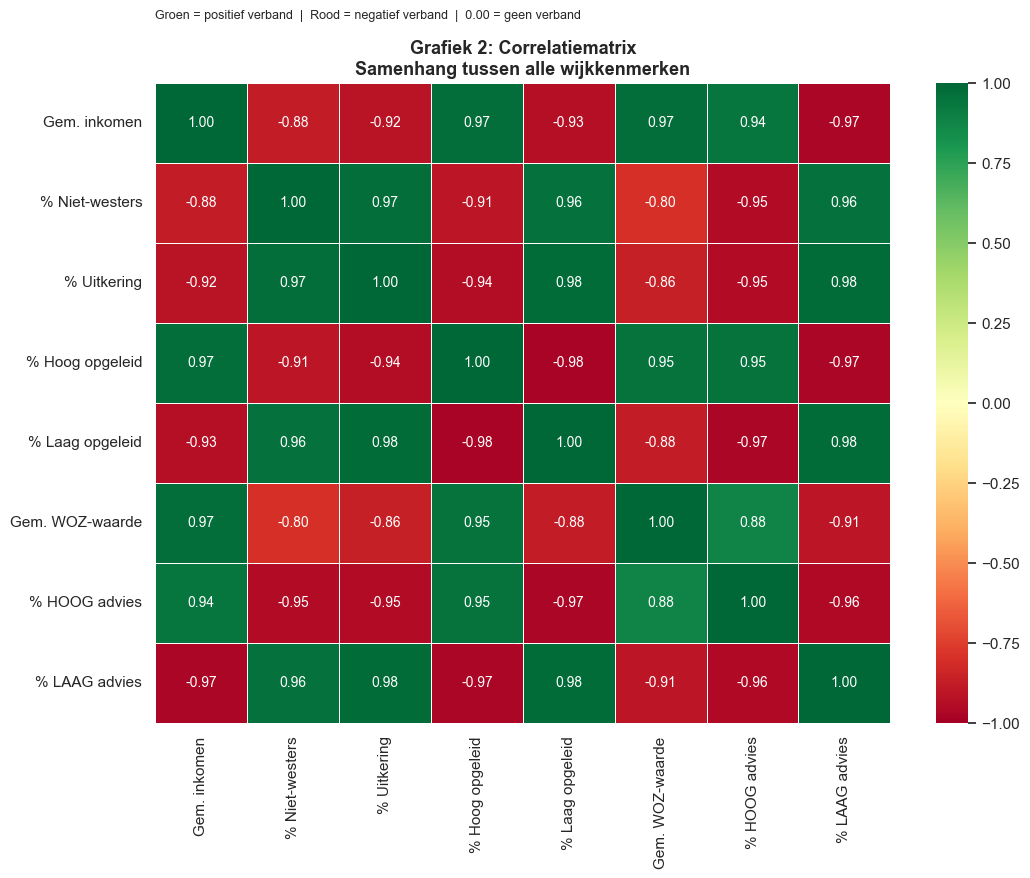

HOE LEES JE DIT?
  De cel op (rij=Gem. inkomen, kolom=% HOOG advies) bevat de correlatie
  tussen inkomen en % hoog advies: r = 0.94
  → Hoe hoger het inkomen in een wijk, hoe meer hoge adviezen.
  De correlatie tussen % niet-westers en % hoog advies: r = -0.95
  → Wijken met meer niet-westerse inwoners hebben gemiddeld minder hoge adviezen.


In [8]:
# Visualisatie als heatmap
fig, ax = plt.subplots(figsize=(11, 9))

# mooiere kolomnamen voor in de grafiek
labels = {
    'gem_inkomen':       'Gem. inkomen',
    'pct_niet_westers':  '% Niet-westers',
    'pct_uitkering':     '% Uitkering',
    'pct_hoog_opgeleid': '% Hoog opgeleid',
    'pct_laag_opgeleid': '% Laag opgeleid',
    'gem_woz':           'Gem. WOZ-waarde',
    'pct_hoog_advies':   '% HOOG advies',
    'pct_laag_advies':   '% LAAG advies',
}
corr_renamed = corr_matrix.rename(index=labels, columns=labels)

sns.heatmap(
    corr_renamed, annot=True, cmap='RdYlGn', center=0,
    vmin=-1, vmax=1, fmt='.2f', linewidths=0.5,
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Grafiek 2: Correlatiematrix\nSamenhang tussen alle wijkkenmerken', 
             fontsize=13, fontweight='bold')

# uitleg bij de grafiek
ax.text(0, -0.8, 'Groen = positief verband  |  Rood = negatief verband  |  0.00 = geen verband',
        fontsize=9, transform=ax.transData)

plt.tight_layout()
plt.savefig('uitleg_grafiek2_correlatiematrix.png', dpi=130, bbox_inches='tight')
plt.show()

print('HOE LEES JE DIT?')
print('  De cel op (rij=Gem. inkomen, kolom=% HOOG advies) bevat de correlatie')
r_ink = corr_matrix.loc['gem_inkomen','pct_hoog_advies']
print(f'  tussen inkomen en % hoog advies: r = {r_ink:.2f}')
print(f'  → Hoe hoger het inkomen in een wijk, hoe meer hoge adviezen.')
r_nw  = corr_matrix.loc['pct_niet_westers','pct_hoog_advies']
print(f'  De correlatie tussen % niet-westers en % hoog advies: r = {r_nw:.2f}')
print(f'  → Wijken met meer niet-westerse inwoners hebben gemiddeld minder hoge adviezen.')

---
## DEEL 5 — Grafiek 3: Adviestrend 2018–2024

**Wat laat deze grafiek zien?**  
De trend in adviestypes door de jaren heen, voor heel Amsterdam samen.

**Hoe worden deze percentages berekend?**  
Voor elk schooljaar berekenen we het **gemiddelde percentage** over alle wijken en scholen.

**Wat zoeken we?**  
Of na 2023-2024 (invoering doorstroomtoets) het % hogere adviezen is gestegen.

In [9]:
# Stap voor stap berekening tonen
print('STAP 1: Per schooljaar en adviestype het gemiddelde % berekenen')
trend = (
    duo_df
    .groupby(['schooljaar','advies_type'])['pct']
    .mean()
    .round(2)
    .reset_index()
)
display(trend.pivot(index='schooljaar', columns='advies_type', values='pct').round(1))

print()
print('STAP 2: Vergelijk 2022-2023 (eindtoets) met 2023-2024 (doorstroomtoets)')
voor = trend[trend['schooljaar']=='2022-2023'].set_index('advies_type')['pct']
na   = trend[trend['schooljaar']=='2023-2024'].set_index('advies_type')['pct']
vergelijk = pd.DataFrame({'2022-2023': voor, '2023-2024': na})
vergelijk['verandering'] = (vergelijk['2023-2024'] - vergelijk['2022-2023']).round(2)
vergelijk['richting'] = vergelijk['verandering'].apply(lambda v: '↑ stijging' if v > 0 else '↓ daling')
display(vergelijk)

STAP 1: Per schooljaar en adviestype het gemiddelde % berekenen


advies_type,HAVO,HAVO/VWO,Praktijkonderwijs,VMBO-BBL,VMBO-KBL,VMBO-TL,VMBO-TL/HAVO,VWO
schooljaar,,,,,,,,
2018-2019,1.6,0.8,0.9,1.5,1.7,2.0,0.9,1.1
2019-2020,1.6,0.8,0.9,1.5,1.7,2.0,0.9,1.0
2020-2021,1.6,0.8,0.9,1.5,1.7,2.0,0.9,1.0
2021-2022,1.6,0.8,0.9,1.5,1.7,2.0,0.9,1.1
2022-2023,1.6,0.8,0.8,1.5,1.7,2.0,0.9,1.1
2023-2024,1.6,0.8,0.9,1.5,1.7,2.0,0.9,1.1



STAP 2: Vergelijk 2022-2023 (eindtoets) met 2023-2024 (doorstroomtoets)


,2022-2023,2023-2024,verandering,richting
advies_type,,,,
HAVO,1.59,1.58,-0.01,↓ daling
HAVO/VWO,0.76,0.76,0.00,↓ daling
Praktijkonderwijs,0.85,0.86,0.01,↑ stijging
VMBO-BBL,1.49,1.52,0.03,↑ stijging
VMBO-KBL,1.73,1.72,-0.01,↓ daling
VMBO-TL,2.05,2.05,0.00,↓ daling
VMBO-TL/HAVO,0.88,0.90,0.02,↑ stijging
VWO,1.11,1.10,-0.01,↓ daling


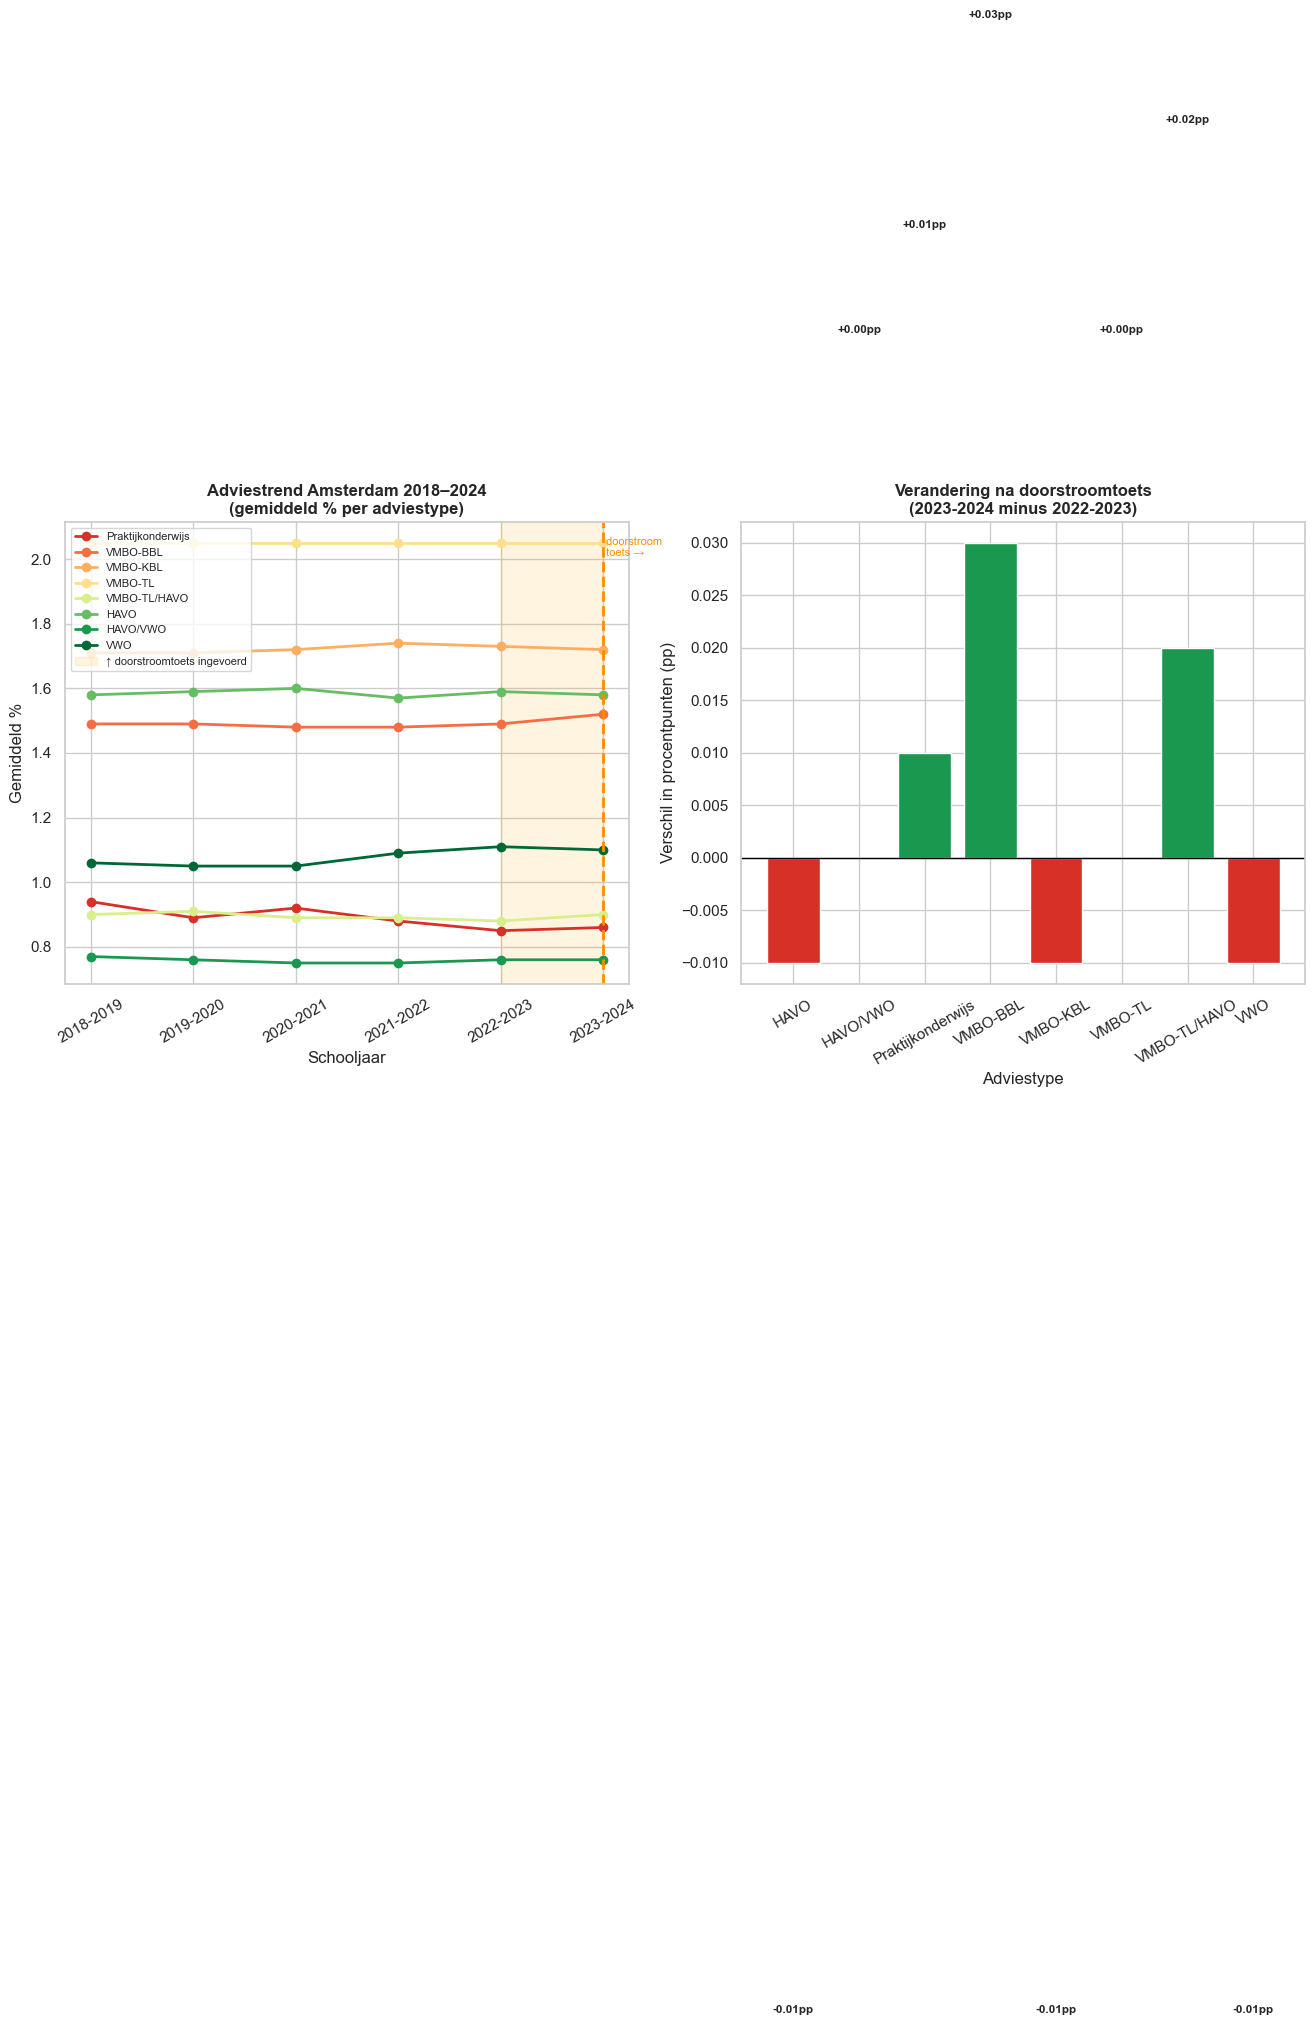

HOE LEES JE DIT?
  % hoog advies vóór doorstroomtoets (2022-2023): 3.5%
  % hoog advies ná  doorstroomtoets (2023-2024): 3.4%
  Verschil: -0.0 procentpunten

  Groene balken = meer leerlingen met dat advies na de doorstroomtoets
  Rode balken   = minder leerlingen met dat advies na de doorstroomtoets


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Links: lijndiagram trend ---
ax = axes[0]
for advies in ADVIES_TYPEN:
    subset = trend[trend['advies_type'] == advies]
    ax.plot(subset['schooljaar'], subset['pct'],
            marker='o', label=advies, color=ADVIES_KLEUREN[advies], linewidth=2)

ax.axvspan('2022-2023', '2023-2024', alpha=0.12, color='orange',
           label='↑ doorstroomtoets ingevoerd')
ax.set_title('Adviestrend Amsterdam 2018–2024\n(gemiddeld % per adviestype)', fontweight='bold')
ax.set_xlabel('Schooljaar')
ax.set_ylabel('Gemiddeld %')
ax.legend(fontsize=8, loc='upper left')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# annotatie: verticale lijn bij doorstroomtoets
ax.axvline('2023-2024', color='darkorange', linestyle='--', linewidth=2)
ax.text('2023-2024', ax.get_ylim()[1]*0.95, ' doorstroom\n toets →',
        fontsize=8, color='darkorange')

# --- Rechts: staafdiagram verandering ---
ax2 = axes[1]
vergelijk_reset = vergelijk.reset_index()
kleuren_v = ['#1a9850' if v >= 0 else '#d73027' for v in vergelijk_reset['verandering']]
bars = ax2.bar(vergelijk_reset['advies_type'], vergelijk_reset['verandering'], color=kleuren_v)
ax2.axhline(0, color='black', linewidth=1)

# waarden boven/onder de balken
for bar, v in zip(bars, vergelijk_reset['verandering']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.05 if v >= 0 else -0.1),
             f'{v:+.2f}pp', ha='center', fontsize=8.5, fontweight='bold')

ax2.set_title('Verandering na doorstroomtoets\n(2023-2024 minus 2022-2023)', fontweight='bold')
ax2.set_xlabel('Adviestype')
ax2.set_ylabel('Verschil in procentpunten (pp)')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('uitleg_grafiek3_adviestrend.png', dpi=130, bbox_inches='tight')
plt.show()

havo_vwo_voor = trend[(trend['schooljaar']=='2022-2023') & (trend['advies_type'].isin(['HAVO','HAVO/VWO','VWO']))]['pct'].sum()
havo_vwo_na   = trend[(trend['schooljaar']=='2023-2024') & (trend['advies_type'].isin(['HAVO','HAVO/VWO','VWO']))]['pct'].sum()
print('HOE LEES JE DIT?')
print(f'  % hoog advies vóór doorstroomtoets (2022-2023): {havo_vwo_voor:.1f}%')
print(f'  % hoog advies ná  doorstroomtoets (2023-2024): {havo_vwo_na:.1f}%')
print(f'  Verschil: {havo_vwo_na - havo_vwo_voor:+.1f} procentpunten')
print()
print('  Groene balken = meer leerlingen met dat advies na de doorstroomtoets')
print('  Rode balken   = minder leerlingen met dat advies na de doorstroomtoets')

---
## DEEL 6 — Grafiek 4: Bijstelling per wijk (doorstroomtoets-effect)

**Wat laat deze grafiek zien?**  
Welk percentage leerlingen een **omhoog bijgesteld advies** heeft gekregen in 2023-2024.

**Formule:**
```
% bijgesteld = (aantal bijgesteld hoger / totaal leerlingen in wijk) × 100
```

**Wat verwacht je?**  
Armere wijken zouden meer bijstellingen moeten hebben, want die kinderen werden vaker onderschat.

In [11]:
# Stap voor stap
print('BEREKENING % bijgesteld per wijk:')
display(bij_wijk[['wijk_naam','stadsdeel','gem_inkomen','totaal','bijgesteld','pct_bijgesteld']]
        .sort_values('pct_bijgesteld', ascending=False).reset_index(drop=True))

print()
print('Toelichting:')
voorbeeld = bij_wijk.sort_values('pct_bijgesteld', ascending=False).iloc[0]
print(f'  Meeste bijstelling: {voorbeeld["wijk_naam"]}')
print(f'  → {voorbeeld["bijgesteld"]} leerlingen bijgesteld / {voorbeeld["totaal"]} totaal × 100 = {voorbeeld["pct_bijgesteld"]:.1f}%')
print(f'  Gemiddeld inkomen: €{voorbeeld["gem_inkomen"]:.0f}k (arme wijk → veel bijstelling = verwacht)')

BEREKENING % bijgesteld per wijk:


,wijk_naam,stadsdeel,gem_inkomen,totaal,bijgesteld,pct_bijgesteld
0,Bijlmer-Oost,Zuidoost,19,547,86,15.7
1,Bijlmer-Centrum,Zuidoost,20,570,89,15.6
2,Osdorp,Nieuw-West,23,771,120,15.6
3,Geuzenveld-Slotermeer,Nieuw-West,22,653,99,15.2
4,Gaasperdam / Driemond,Zuidoost,24,711,105,14.8
5,Noord-Oost,Noord,26,778,112,14.4
6,Slotervaart,Nieuw-West,26,636,91,14.3
7,Bos en Lommer,West,24,732,103,14.1
8,Indische Buurt,Oost,30,672,93,13.8
9,Noord-West,Noord,28,672,91,13.5



Toelichting:
  Meeste bijstelling: Bijlmer-Oost
  → 86 leerlingen bijgesteld / 547 totaal × 100 = 15.7%
  Gemiddeld inkomen: €19k (arme wijk → veel bijstelling = verwacht)


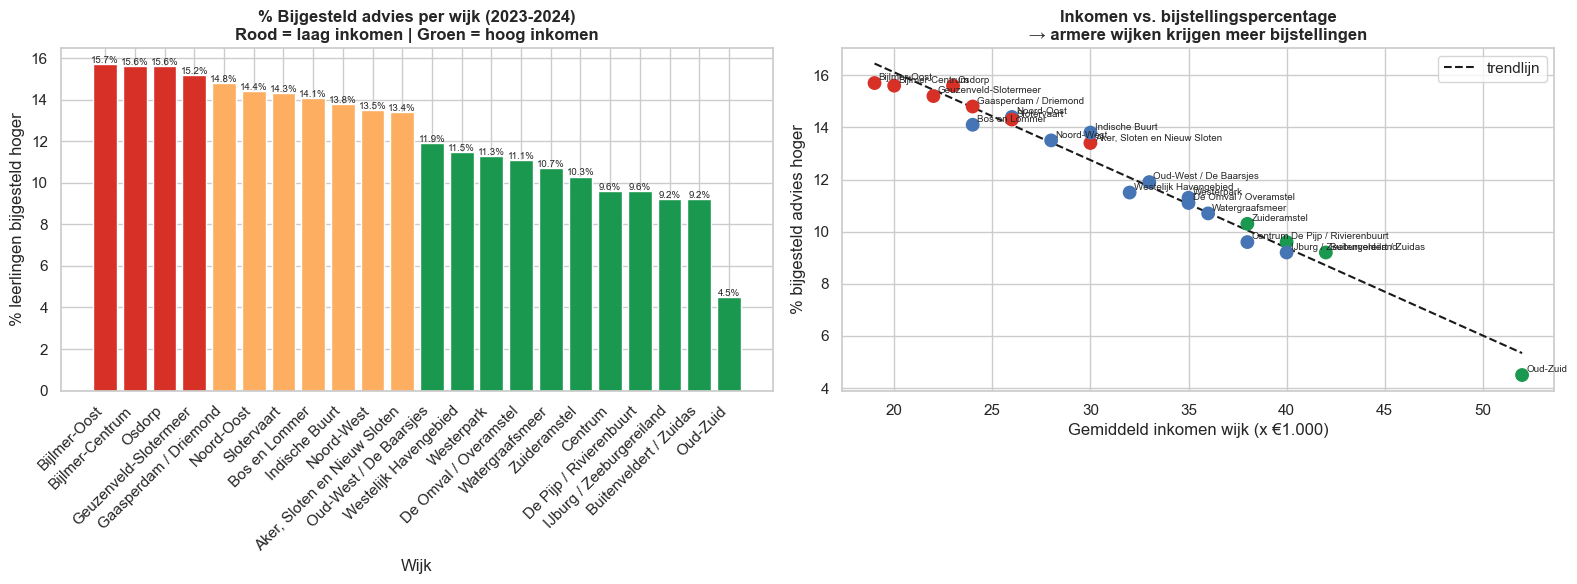

HOE LEES JE DIT?
  Correlatie inkomen ↔ bijstelling: r = -0.99
  → Negatief verband: arme wijken (laag inkomen) → meer bijstellingen
  Dat is precies wat de doorstroomtoets beoogt!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bij_gesorteerd = bij_wijk.sort_values('pct_bijgesteld', ascending=False)

# --- Links: bijstelling per wijk ---
ax = axes[0]
kleuren_bij = []
for inc in bij_gesorteerd['gem_inkomen']:
    if inc < 24:   kleuren_bij.append('#d73027')   # rood = arm
    elif inc < 32: kleuren_bij.append('#fdae61')   # oranje = midden
    else:          kleuren_bij.append('#1a9850')   # groen = rijk

bars = ax.bar(bij_gesorteerd['wijk_naam'], bij_gesorteerd['pct_bijgesteld'], color=kleuren_bij)
for bar, val in zip(bars, bij_gesorteerd['pct_bijgesteld']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%', ha='center', fontsize=7)

ax.set_title('% Bijgesteld advies per wijk (2023-2024)\nRood = laag inkomen | Groen = hoog inkomen',
             fontweight='bold')
ax.set_ylabel('% leerlingen bijgesteld hoger')
ax.set_xlabel('Wijk')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Rechts: scatter bijstelling vs inkomen ---
ax2 = axes[1]
ax2.scatter(bij_wijk['gem_inkomen'], bij_wijk['pct_bijgesteld'],
            c=[wijk_kleur(s) for s in bij_wijk['stadsdeel']], s=80, zorder=3)

# namen naast de punten
for _, rij in bij_wijk.iterrows():
    ax2.annotate(rij['wijk_naam'], (rij['gem_inkomen'], rij['pct_bijgesteld']),
                 fontsize=7, xytext=(3, 2), textcoords='offset points')

# trendlijn
z = np.polyfit(bij_wijk['gem_inkomen'], bij_wijk['pct_bijgesteld'], 1)
p = np.poly1d(z)
x_lijn = np.linspace(bij_wijk['gem_inkomen'].min(), bij_wijk['gem_inkomen'].max(), 100)
ax2.plot(x_lijn, p(x_lijn), 'k--', linewidth=1.5, label='trendlijn')
ax2.legend()

ax2.set_xlabel('Gemiddeld inkomen wijk (x €1.000)')
ax2.set_ylabel('% bijgesteld advies hoger')
ax2.set_title('Inkomen vs. bijstellingspercentage\n→ armere wijken krijgen meer bijstellingen',
              fontweight='bold')

plt.tight_layout()
plt.savefig('uitleg_grafiek4_bijstelling.png', dpi=130, bbox_inches='tight')
plt.show()

from scipy import stats as scipy_stats
r_bij, p_bij = scipy_stats.pearsonr(bij_wijk['gem_inkomen'], bij_wijk['pct_bijgesteld'])
print(f'HOE LEES JE DIT?')
print(f'  Correlatie inkomen ↔ bijstelling: r = {r_bij:.2f}')
print(f'  → Negatief verband: arme wijken (laag inkomen) → meer bijstellingen')
print(f'  Dat is precies wat de doorstroomtoets beoogt!')

---
## DEEL 7 — Kaart: Amsterdam (scattermap)

**Wat laat de kaart zien?**  
Elke cirkel is een wijk. De kleur en grootte geven het % hoog advies aan:
- **Groen / groot** = veel hoge adviezen
- **Rood / klein** = weinig hoge adviezen

**Hoe werkt de kaart?**  
Elke wijk heeft een **breedtegraad** (lat) en **lengtegraad** (lon) in de dataset.
Die coördinaten worden op een kaart geplaatst via Plotly `scatter_map`.

In [13]:
# Toon de coordinaten per wijk
print('COÖRDINATEN per wijk (voor de kaart):')
display(wijken_df[['wijk_naam','stadsdeel','lat','lon','pct_hoog_advies']]
        .sort_values('pct_hoog_advies', ascending=False).reset_index(drop=True))

print()
print('UITLEG coördinaten:')
print('  lat = breedtegraad (Noord-Zuid as in Nederland: ~52.3 tot 52.4)')
print('  lon = lengtegraad  (Oost-West as in Nederland: ~4.8 tot 5.0)')
print()
print('  Amsterdam centrum ligt op lat=52.373, lon=4.893')
centrum = wijken_df[wijken_df['wijk_naam']=='Centrum'][['lat','lon']].values
if len(centrum) > 0:
    print(f'  Onze data: lat={centrum[0][0]}, lon={centrum[0][1]}')

COÖRDINATEN per wijk (voor de kaart):


,wijk_naam,stadsdeel,lat,lon,pct_hoog_advies
0,Oud-Zuid,Zuid,52.349,4.877,4.6
1,Buitenveldert / Zuidas,Zuid,52.335,4.872,4.2
2,Zuideramstel,Zuid,52.330,4.908,4.1
3,IJburg / Zeeburgereiland,Oost,52.358,4.978,4.0
4,Centrum,Centrum,52.373,4.893,3.9
5,Westerpark,West,52.387,4.868,3.9
6,Watergraafsmeer,Oost,52.354,4.934,3.8
7,De Omval / Overamstel,Oost,52.336,4.928,3.8
8,De Pijp / Rivierenbuurt,Zuid,52.351,4.898,3.8
9,"Aker, Sloten en Nieuw Sloten",Nieuw-West,52.345,4.816,3.7



UITLEG coördinaten:
  lat = breedtegraad (Noord-Zuid as in Nederland: ~52.3 tot 52.4)
  lon = lengtegraad  (Oost-West as in Nederland: ~4.8 tot 5.0)

  Amsterdam centrum ligt op lat=52.373, lon=4.893
  Onze data: lat=52.373, lon=4.893


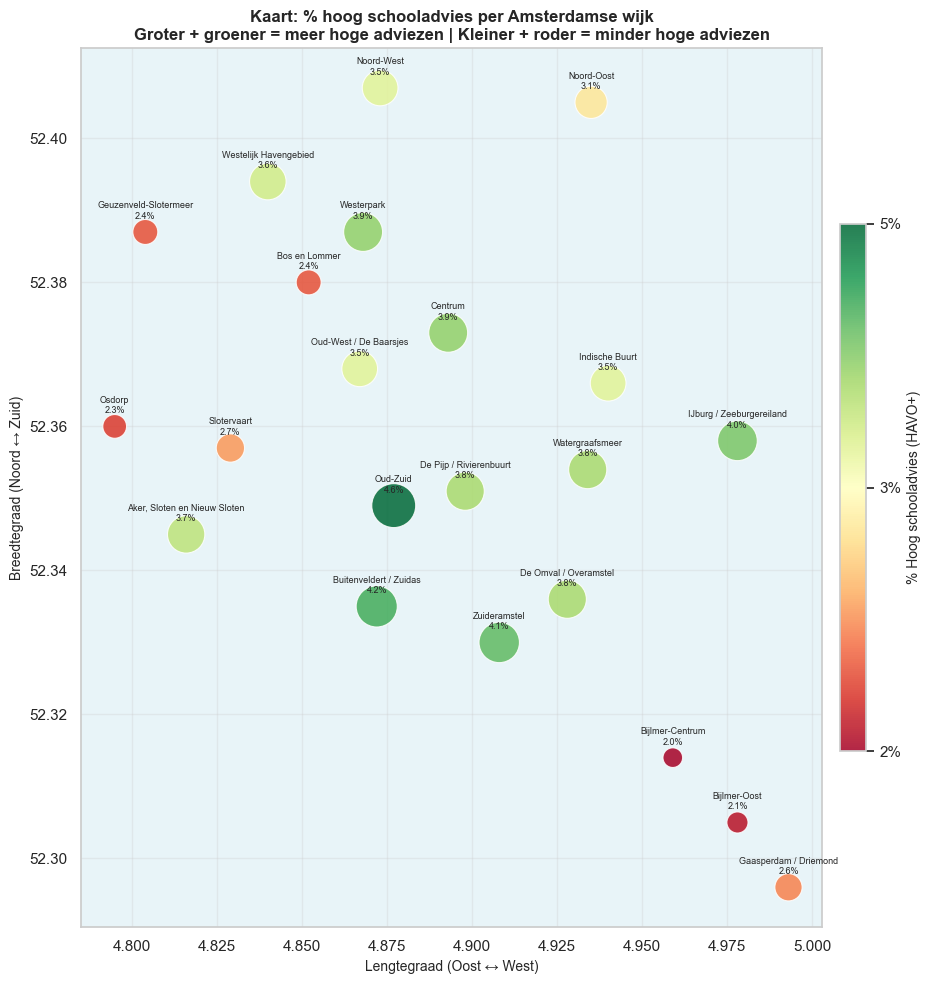

HOE LEES JE DIT?
  - Groene, grote cirkel = wijk met veel hoge adviezen (bijv. Oud-Zuid in het zuiden)
  - Rode, kleine cirkel  = wijk met weinig hoge adviezen (bijv. Bijlmer in het zuidoosten)
  - De positie op de kaart = de geografische ligging van de wijk
  - Kleurschaal loopt van 2.0% (rood) tot 4.6% (groen)


In [14]:
# Statische versie van de kaart (matplotlib, zonder internet)
fig, ax = plt.subplots(figsize=(10, 10))

# normaliseer pct_hoog_advies voor kleur en grootte
df_kaart = wijken_df.dropna(subset=['lat','lon','pct_hoog_advies']).copy()
pct_max = df_kaart['pct_hoog_advies'].max()
pct_min = df_kaart['pct_hoog_advies'].min()
df_kaart['norm'] = (df_kaart['pct_hoog_advies'] - pct_min) / (pct_max - pct_min)

# kleur via colormap rood-geel-groen
cmap = plt.cm.RdYlGn
kleuren_kaart = [cmap(n) for n in df_kaart['norm']]
groottes = 200 + df_kaart['norm'] * 800   # kleine circles voor lage %, grote voor hoge %

scatter = ax.scatter(df_kaart['lon'], df_kaart['lat'],
                     c=df_kaart['norm'], cmap='RdYlGn',
                     s=groottes, alpha=0.85, edgecolors='white', linewidth=0.8, zorder=3)

# wijk-namen
for _, rij in df_kaart.iterrows():
    ax.annotate(
        f"{rij['wijk_naam']}\n{rij['pct_hoog_advies']:.1f}%",
        (rij['lon'], rij['lat']),
        fontsize=6.5, ha='center', va='bottom', xytext=(0, 8),
        textcoords='offset points'
    )

# kleurenbalk
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('% Hoog schooladvies (HAVO+)', fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels([f'{pct_min:.0f}%', f'{(pct_min+pct_max)/2:.0f}%', f'{pct_max:.0f}%'])

ax.set_xlabel('Lengtegraad (Oost ↔ West)', fontsize=10)
ax.set_ylabel('Breedtegraad (Noord ↔ Zuid)', fontsize=10)
ax.set_title('Kaart: % hoog schooladvies per Amsterdamse wijk\n'
             'Groter + groener = meer hoge adviezen | Kleiner + roder = minder hoge adviezen',
             fontweight='bold', fontsize=12)
ax.set_facecolor('#e8f4f8')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('uitleg_kaart_amsterdam.png', dpi=130, bbox_inches='tight')
plt.show()

print('HOE LEES JE DIT?')
print('  - Groene, grote cirkel = wijk met veel hoge adviezen (bijv. Oud-Zuid in het zuiden)')
print('  - Rode, kleine cirkel  = wijk met weinig hoge adviezen (bijv. Bijlmer in het zuidoosten)')
print('  - De positie op de kaart = de geografische ligging van de wijk')
print(f'  - Kleurschaal loopt van {pct_min:.1f}% (rood) tot {pct_max:.1f}% (groen)')

---
## DEEL 8 — Grafiek 5: Regressiemodel (voorspelling)

**Wat is een regressiemodel?**  
Een model dat probeert te *voorspellen* hoe hoog het % hoog advies in een wijk zou moeten zijn, op basis van:
- Gemiddeld inkomen
- % niet-westers
- % uitkering
- % laag opgeleid

**Formule (lineaire regressie):**
```
voorspeld % = a₁ × inkomen + a₂ × niet_westers + a₃ × uitkering + a₄ × laag_opgeleid + b
```
De waarden a₁...a₄ (coëfficiënten) worden automatisch berekend door Python.

**Residu = verschil tussen werkelijk en voorspeld:**
```
residu = werkelijk % - voorspeld %
positief residu → wijk doet het BETER dan verwacht
negatief residu → wijk doet het SLECHTER dan verwacht
```

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

features = ['gem_inkomen','pct_niet_westers','pct_uitkering','pct_laag_opgeleid']
target   = 'pct_hoog_advies'

model_data = wijken_df[features + [target,'wijk_naam','stadsdeel']].dropna()
X = model_data[features].values
y = model_data[target].values

# standaardiseren zodat we coëfficiënten kunnen vergelijken
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_sc, y)

y_pred = model.predict(X_sc)
residu = y - y_pred

# R² berekenen
ss_res = ((y - y_pred)**2).sum()
ss_tot = ((y - y.mean())**2).sum()
r2     = 1 - ss_res / ss_tot

model_data = model_data.copy()
model_data['voorspeld'] = y_pred.round(1)
model_data['werkelijk'] = y.round(1)
model_data['residu']    = residu.round(1)
model_data['prestatie'] = model_data['residu'].apply(
    lambda r: 'Beter dan verwacht' if r > 3 else 'Slechter dan verwacht' if r < -3 else 'Zoals verwacht'
)

print(f'MODEL R² = {r2:.3f} → het model verklaart {r2*100:.1f}% van de variatie in schooladvies')
print()
print('COËFFICIËNTEN (gewicht van elke factor):')
for naam, coef in zip(features, model.coef_):
    richting = '↑ positief' if coef > 0 else '↓ negatief'
    print(f'  {naam:<25} coef = {coef:+.2f}  {richting}')
print(f'  intercept (b) = {model.intercept_:.2f}')
print()
print('WERKELIJK vs. VOORSPELD vs. RESIDU per wijk:')
display(model_data[['wijk_naam','stadsdeel','werkelijk','voorspeld','residu','prestatie']]
        .sort_values('residu', ascending=False).reset_index(drop=True))

MODEL R² = 0.963 → het model verklaart 96.3% van de variatie in schooladvies

COËFFICIËNTEN (gewicht van elke factor):
  gem_inkomen               coef = +0.22  ↑ positief
  pct_niet_westers          coef = -0.37  ↓ negatief
  pct_uitkering             coef = +0.37  ↑ positief
  pct_laag_opgeleid         coef = -0.52  ↓ negatief
  intercept (b) = 3.34

WERKELIJK vs. VOORSPELD vs. RESIDU per wijk:


,wijk_naam,stadsdeel,werkelijk,voorspeld,residu,prestatie
0,"Aker, Sloten en Nieuw Sloten",Nieuw-West,3.7,3.3,0.4,Zoals verwacht
1,Noord-West,Noord,3.5,3.3,0.2,Zoals verwacht
2,Indische Buurt,Oost,3.5,3.4,0.1,Zoals verwacht
3,Oud-Zuid,Zuid,4.6,4.5,0.1,Zoals verwacht
4,Geuzenveld-Slotermeer,Nieuw-West,2.4,2.3,0.1,Zoals verwacht
5,Westerpark,West,3.9,3.8,0.1,Zoals verwacht
6,Bijlmer-Oost,Zuidoost,2.1,2.0,0.1,Zoals verwacht
7,Gaasperdam / Driemond,Zuidoost,2.6,2.5,0.1,Zoals verwacht
8,Zuideramstel,Zuid,4.1,4.0,0.1,Zoals verwacht
9,Centrum,Centrum,3.9,3.9,-0.0,Zoals verwacht


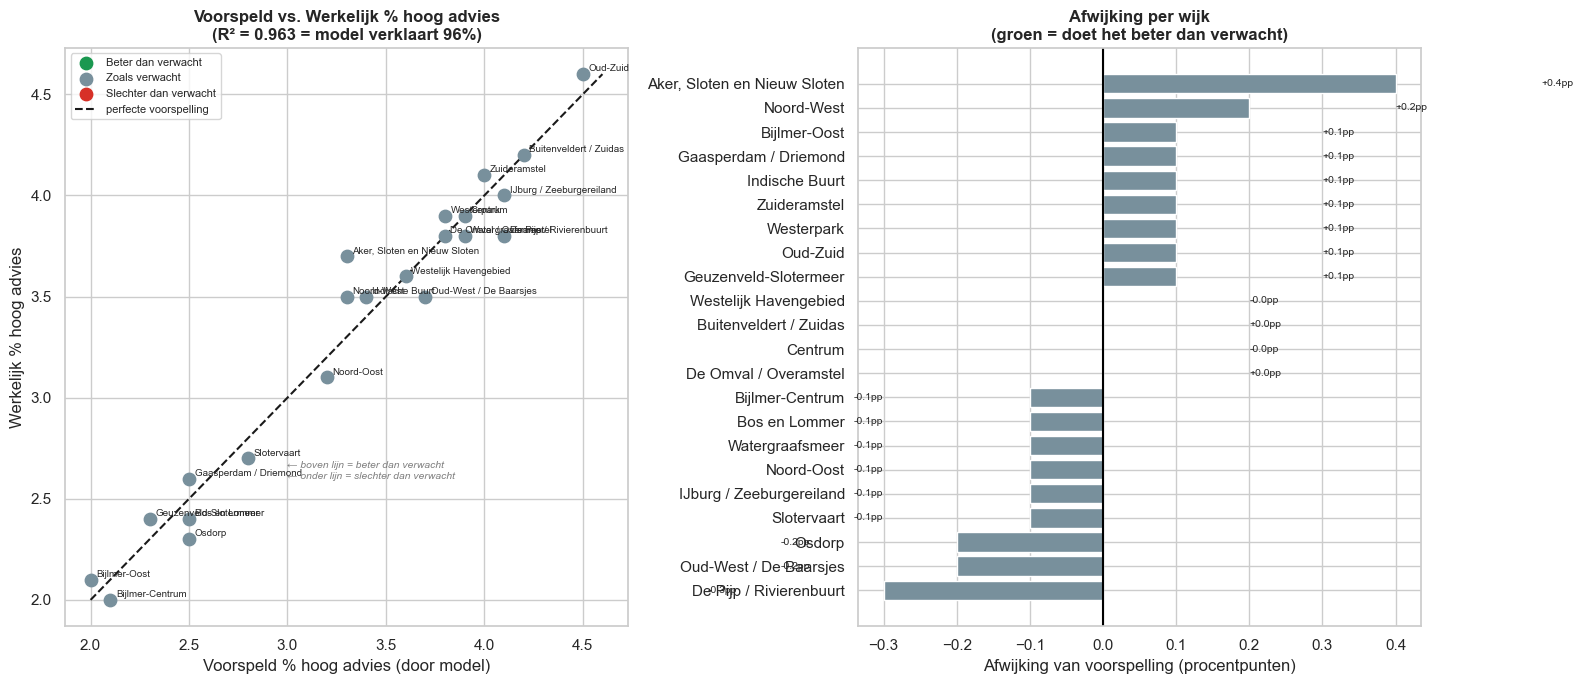

HOE LEES JE DIT?
  Beter dan verwacht:    []
  Slechter dan verwacht: []

  Een wijk kan BETER presteren dan verwacht doordat:
  → Goede scholen, extra ondersteuning, betrokken ouders, enz.
  Een wijk kan SLECHTER presteren doordat:
  → Taalbarrières, schoolkwaliteit, enz. die ons model niet meet


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

prestatie_kleuren = {
    'Beter dan verwacht':    '#1a9850',
    'Zoals verwacht':        '#78909c',
    'Slechter dan verwacht': '#d73027',
}

# --- Links: voorspeld vs. werkelijk ---
ax = axes[0]
for prest, kleur in prestatie_kleuren.items():
    sub = model_data[model_data['prestatie'] == prest]
    ax.scatter(sub['voorspeld'], sub['werkelijk'], color=kleur,
               label=prest, s=80, zorder=3)
    for _, rij in sub.iterrows():
        ax.annotate(rij['wijk_naam'], (rij['voorspeld'], rij['werkelijk']),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')

# diagonale lijn = perfecte voorspelling
mn = min(model_data['voorspeld'].min(), model_data['werkelijk'].min())
mx = max(model_data['voorspeld'].max(), model_data['werkelijk'].max())
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='perfecte voorspelling')

ax.set_xlabel('Voorspeld % hoog advies (door model)')
ax.set_ylabel('Werkelijk % hoog advies')
ax.set_title(f'Voorspeld vs. Werkelijk % hoog advies\n(R² = {r2:.3f} = model verklaart {r2*100:.0f}%)',
             fontweight='bold')
ax.legend(fontsize=8)

# uitleg diagonaal
ax.text(mn+1, mx-2, '← boven lijn = beter dan verwacht\n← onder lijn = slechter dan verwacht',
        fontsize=7.5, style='italic', color='gray')

# --- Rechts: residu per wijk ---
ax2 = axes[1]
gesorteerd_res = model_data.sort_values('residu')
kleuren_res = [prestatie_kleuren[p] for p in gesorteerd_res['prestatie']]

bars = ax2.barh(gesorteerd_res['wijk_naam'], gesorteerd_res['residu'], color=kleuren_res)
ax2.axvline(0, color='black', linewidth=1.5)

for bar, val in zip(bars, gesorteerd_res['residu']):
    x_pos = val + (0.2 if val >= 0 else -0.2)
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:+.1f}pp', va='center', fontsize=7.5,
             ha='left' if val >= 0 else 'right')

ax2.set_xlabel('Afwijking van voorspelling (procentpunten)')
ax2.set_title('Afwijking per wijk\n(groen = doet het beter dan verwacht)',
              fontweight='bold')

plt.tight_layout()
plt.savefig('uitleg_grafiek5_regressie.png', dpi=130, bbox_inches='tight')
plt.show()

beter    = model_data[model_data['prestatie']=='Beter dan verwacht']['wijk_naam'].tolist()
slechter = model_data[model_data['prestatie']=='Slechter dan verwacht']['wijk_naam'].tolist()
print('HOE LEES JE DIT?')
print(f'  Beter dan verwacht:    {beter}')
print(f'  Slechter dan verwacht: {slechter}')
print()
print('  Een wijk kan BETER presteren dan verwacht doordat:')
print('  → Goede scholen, extra ondersteuning, betrokken ouders, enz.')
print('  Een wijk kan SLECHTER presteren doordat:')
print('  → Taalbarrières, schoolkwaliteit, enz. die ons model niet meet')

---
## DEEL 9 — Adviesverdeling als heatmap

**Wat is een heatmap?**  
Een tabel waarbij de kleur de waarde aangeeft. Groen = hoog %, rood = laag %.

**Wat zie je hier?**  
Per wijk (rij) en per adviestype (kolom) het gemiddelde percentage leerlingen.

In [17]:
# Heatmap opbouwen
print('STAP 1: gemiddeld % per wijk × adviestype (alle jaren samen)')
heatmap_data = (
    duo_df
    .groupby(['wijk_naam','advies_type'], as_index=False)
    .agg(gem_pct=('pct','mean'))
)

heatmap_pivot = (
    heatmap_data
    .pivot(index='wijk_naam', columns='advies_type', values='gem_pct')
    .fillna(0)
)
# sorteren: rijkste wijken bovenaan (meeste VWO)
if 'VWO' in heatmap_pivot.columns:
    heatmap_pivot = heatmap_pivot.sort_values('VWO', ascending=False)

# kolommen in volgorde laag → hoog
kolom_volgorde = [a for a in ADVIES_TYPEN if a in heatmap_pivot.columns]
heatmap_pivot  = heatmap_pivot[kolom_volgorde]

print('Ruwe data (eerste 5 rijen):')
display(heatmap_pivot.round(1).head())

print()
print('STAP 2: visualiseren als heatmap (groen = hoog %, rood = laag %)')

STAP 1: gemiddeld % per wijk × adviestype (alle jaren samen)
Ruwe data (eerste 5 rijen):


advies_type,Praktijkonderwijs,VMBO-BBL,VMBO-KBL,VMBO-TL,VMBO-TL/HAVO,HAVO,HAVO/VWO,VWO
wijk_naam,,,,,,,,
Oud-Zuid,0.2,0.5,0.8,1.3,0.9,1.8,1.0,1.8
Buitenveldert / Zuidas,0.5,0.9,1.2,1.6,0.9,1.8,0.9,1.5
Zuideramstel,0.6,1.1,1.4,1.8,0.9,1.7,0.9,1.5
Centrum,0.6,1.1,1.4,1.9,0.9,1.8,0.8,1.4
De Pijp / Rivierenbuurt,0.5,0.9,1.2,1.6,0.9,1.7,0.9,1.4



STAP 2: visualiseren als heatmap (groen = hoog %, rood = laag %)


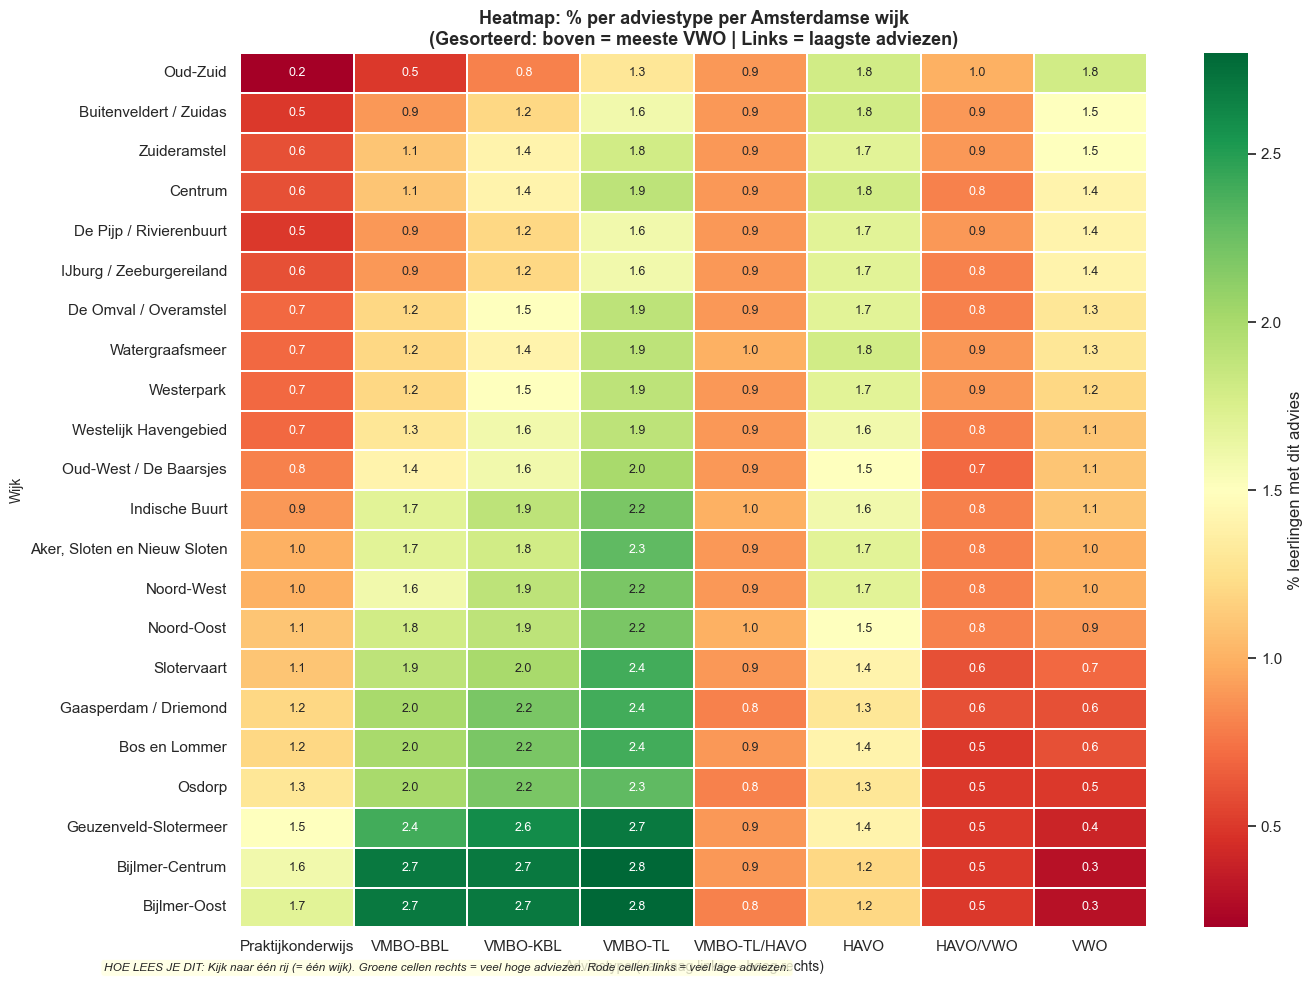

HOE LEES JE DIT?
  - Elke RIJ is een wijk in Amsterdam
  - Elke KOLOM is een adviestype (van Praktijkonderwijs links naar VWO rechts)
  - Het GETAL in de cel = gemiddeld % leerlingen met dat advies in die wijk
  - GROEN = hoog percentage | ROOD = laag percentage
  - Rijke wijken (bovenaan) hebben meer groen rechts (VWO)
  - Arme wijken (onderaan) hebben meer groen links (PrO, VMBO-BBL)


In [18]:
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    heatmap_pivot.round(1), annot=True, fmt='.1f',
    cmap='RdYlGn', linewidths=0.3, linecolor='white',
    annot_kws={'size': 9}, ax=ax,
    cbar_kws={'label': '% leerlingen met dit advies'}
)

ax.set_title('Heatmap: % per adviestype per Amsterdamse wijk\n'
             '(Gesorteerd: boven = meeste VWO | Links = laagste adviezen)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Adviestype (van laag links → hoog rechts)', fontsize=10)
ax.set_ylabel('Wijk', fontsize=10)

# annotatie
ax.text(-0.15, -0.05,
    'HOE LEES JE DIT: Kijk naar één rij (= één wijk). '
    'Groene cellen rechts = veel hoge adviezen. Rode cellen links = veel lage adviezen.',
    transform=ax.transAxes, fontsize=8.5, style='italic',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('uitleg_grafiek6_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

print('HOE LEES JE DIT?')
print('  - Elke RIJ is een wijk in Amsterdam')
print('  - Elke KOLOM is een adviestype (van Praktijkonderwijs links naar VWO rechts)')
print('  - Het GETAL in de cel = gemiddeld % leerlingen met dat advies in die wijk')
print('  - GROEN = hoog percentage | ROOD = laag percentage')
print('  - Rijke wijken (bovenaan) hebben meer groen rechts (VWO)')
print('  - Arme wijken (onderaan) hebben meer groen links (PrO, VMBO-BBL)')

---
## SAMENVATTING — alle berekeningen op een rij

| Getal | Formule | Voorbeeld |
|-------|---------|----------|
| `pct` (per school) | `aantal / totaal × 100` | 15 HAVO / 80 leerlingen × 100 = 18.8% |
| `pct_hoog_advies` | `%HAVO + %HAVO/VWO + %VWO` | 12 + 8 + 10 = 30% |
| `pct_laag_advies` | `%PrO + %VMBO-BBL + %VMBO-KBL` | 5 + 10 + 12 = 27% |
| `pct_bijgesteld` | `bijgesteld_hoger / totaal × 100` | 8 / 80 × 100 = 10% |
| Pearson correlatie r | `cov(X,Y) / (σX × σY)` | `df.corr()` in Python |
| Regressie residu | `werkelijk - voorspeld` | 32% - 28% = +4pp (beter dan verwacht) |
| R² | `1 - SS_residu / SS_totaal` | 0.96 = model verklaart 96% van variatie |

In [19]:
print('Opgeslagen grafieken:')
import os
folder = r'c:\Users\AAchr\Documents\Casus 2 phyton minor\ROC'
for f in sorted(os.listdir(folder)):
    if f.startswith('uitleg_') and f.endswith('.png'):
        print(f'  ✅ {f}')
print()
print('Notebook klaar!')

Opgeslagen grafieken:
  ✅ uitleg_grafiek1_inkomen_advies.png
  ✅ uitleg_grafiek2_correlatiematrix.png
  ✅ uitleg_grafiek3_adviestrend.png
  ✅ uitleg_grafiek4_bijstelling.png
  ✅ uitleg_grafiek5_regressie.png
  ✅ uitleg_grafiek6_heatmap.png
  ✅ uitleg_kaart_amsterdam.png

Notebook klaar!
